# PEBBLE on Pendulum-v1 — Analysis

Comparing **PEBBLE** (preference-based RL) vs **SAC** (ground-truth reward) on the custom Pendulum-v1 environment with varying target angles.

**Target angles (θ_target):** {0°, −60°, 90°, 120°, −150°}

**Reward function** (from `RL_PA3/pytorch_sac/env_wrappers.py` — `PendulumWrapper`):
$R = -(\Delta\theta^2 + 0.01\dot{\theta}^2 + 0.0008\|\tau\|^2)$ where $\Delta\theta = \text{angle\_normalize}(\theta - \theta_{\text{target}})$.
Max episode length = 1000 steps, reward_scale = 1.0.

**PEBBLE data:** `test_group/theta_{rad}/seed_{seed}/eval.csv` — offline evaluations every 10K steps.

**SAC data:** From `RL_PA3/main_final.ipynb` (SAC trained with ground-truth reward on the same PendulumWrapper, ~55k training steps).

> Note: θ_target = 0° data is not available in the test_group logs.

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11
%matplotlib inline

In [25]:
TEST_GROUP = '/Users/gokul/dev/sem_6/RL/test_group'

# theta in radians -> theta in degrees
THETA_RAD_TO_DEG = {
    -2.61: -150,
    2.09: 120,
    -1.05: -60,
    1.57: 90,
}

SEEDS = ['10', '11', '42', '44', '52', '90', '98']


def load_pebble_data():
    """Load all PEBBLE eval.csv files. Returns dict: theta_deg -> list of DataFrames"""
    all_data = {}
    for theta_rad, theta_deg in THETA_RAD_TO_DEG.items():
        runs = []
        for seed in SEEDS:
            path = os.path.join(TEST_GROUP, f'theta_{theta_rad}', f'seed_{seed}', 'eval.csv')
            if not os.path.exists(path):
                print(f'Warning: {path} not found')
                continue
            df = pd.read_csv(path)
            runs.append(df)
        all_data[theta_deg] = runs
    return all_data


pebble_data = load_pebble_data()
for theta, runs in pebble_data.items():
    print(f'θ = {theta:>4}°  |  {len(runs)} seeds  |  steps: {runs[0]["step"].min()}–{runs[0]["step"].max()}')

θ = -150°  |  7 seeds  |  steps: 0–200000
θ =  120°  |  7 seeds  |  steps: 0–200000
θ =  -60°  |  7 seeds  |  steps: 0–200000
θ =   90°  |  7 seeds  |  steps: 0–200000


In [26]:
def aggregate_runs(runs):
    """Merge runs on step, compute mean and 95% CI of episode_reward."""
    merged = None
    for i, run in enumerate(runs):
        run = run.rename(columns={'episode_reward': f'reward_{i}'})
        if merged is None:
            merged = run[['step', f'reward_{i}']]
        else:
            merged = pd.merge(merged, run[['step', f'reward_{i}']], on='step', how='outer')

    merged = merged.sort_values('step')
    reward_cols = [c for c in merged.columns if c.startswith('reward_')]
    rewards = merged[reward_cols].to_numpy(dtype=float)

    mean = np.nanmean(rewards, axis=1)
    std = np.nanstd(rewards, axis=1)
    n = np.sum(~np.isnan(rewards), axis=1)
    ci95 = 1.96 * std / np.sqrt(n)
    return merged['step'].to_numpy(), mean, ci95


aggregated = {}
for theta, runs in pebble_data.items():
    aggregated[theta] = aggregate_runs(runs)

theta_list = sorted(aggregated.keys())

In [27]:
# SAC final results from main_final.ipynb (custom PendulumWrapper, same env as PEBBLE)
# Evaluations are averages over multiple episodes every 20K steps.
SAC_RESULTS = {
    -150: {'mean': -259.04, 'std': 25.76},
    -60:  {'mean': -1042.91, 'std': 127.34},
    0:    {'mean': -159.41, 'std': 28.21},
    90:   {'mean': -2207.45, 'std': 172.93},
    120:  {'mean': -920.60, 'std': 39.61},
}

print('SAC Final Performance (from RL_PA3/main_final.ipynb, custom PendulumWrapper):')
for theta, v in sorted(SAC_RESULTS.items()):
    print(f'  θ = {theta:>4}°  |  eval return = {v["mean"]:>8.2f} ± {v["std"]:.2f}')

SAC Final Performance (from RL_PA3/main_final.ipynb, custom PendulumWrapper):
  θ = -150°  |  eval return =  -259.04 ± 25.76
  θ =  -60°  |  eval return = -1042.91 ± 127.34
  θ =    0°  |  eval return =  -159.41 ± 28.21
  θ =   90°  |  eval return = -2207.45 ± 172.93
  θ =  120°  |  eval return =  -920.60 ± 39.61


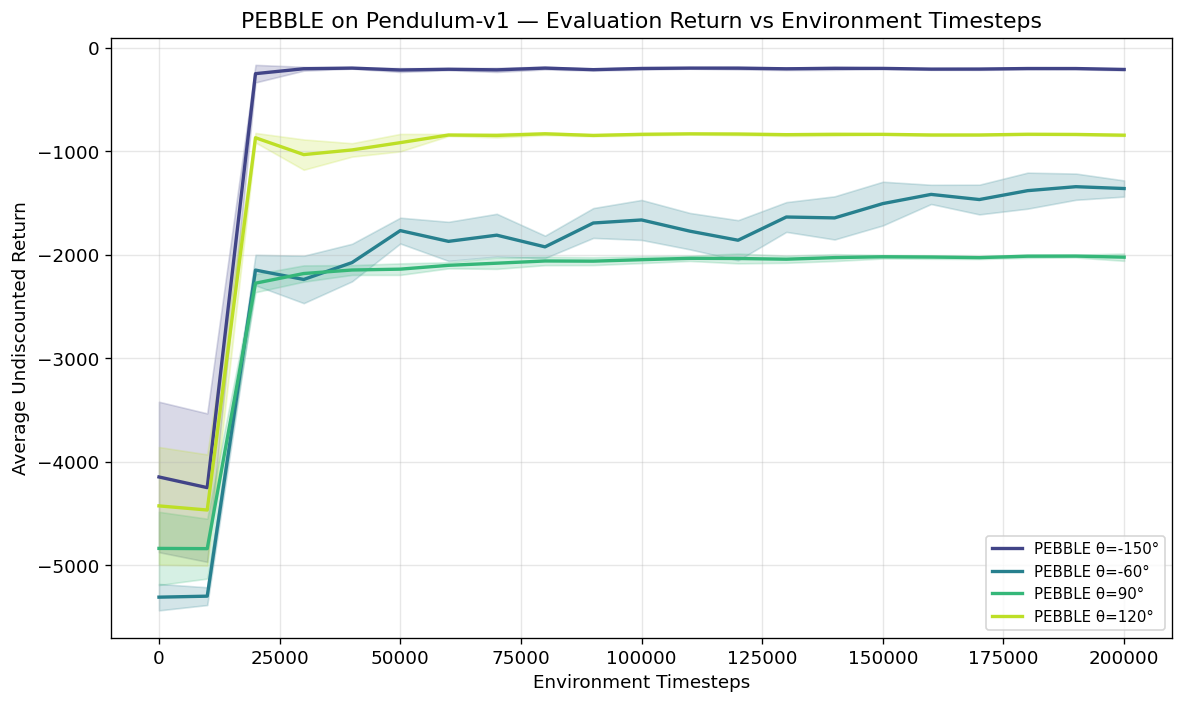

In [28]:
"""
Plot average undiscounted return vs. environment timesteps.
X-axis: Environment Timesteps (not episodes)
Y-axis: Average Undiscounted Return (episode_reward from eval.csv)
Shaded region: 95% confidence interval over 7 seeds
"""
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(aggregated)))

fig, ax = plt.subplots(figsize=(10, 6))

items = sorted(aggregated.items())
for (theta, (step, mean, ci)), color in zip(items, colors):
    ax.plot(step, mean, color=color, linewidth=2, label=f'PEBBLE θ={theta}°')
    ax.fill_between(step, mean - ci, mean + ci, color=color, alpha=0.2)

ax.set_xlabel('Environment Timesteps')
ax.set_ylabel('Average Undiscounted Return')
ax.set_title('PEBBLE on Pendulum-v1 — Evaluation Return vs Environment Timesteps')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

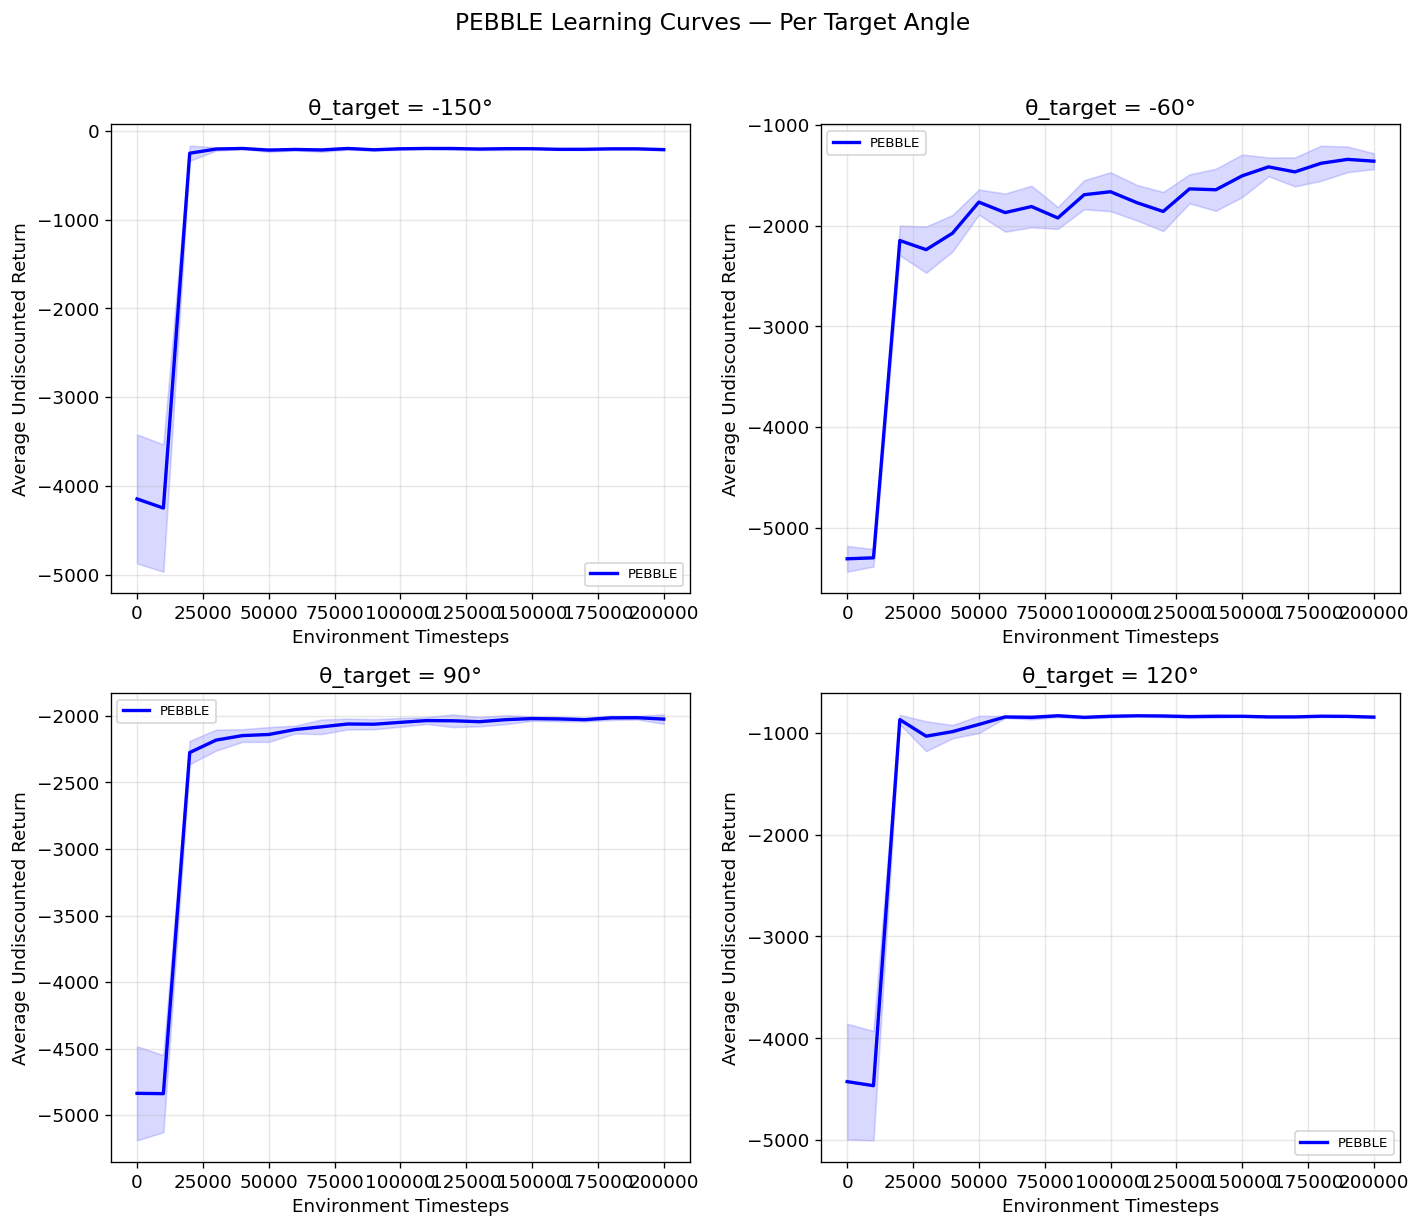

In [29]:
"""Individual plots per target angle"""
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, theta in enumerate(theta_list):
    ax = axes[idx]
    step, mean, ci = aggregated[theta]

    ax.plot(step, mean, 'b-', linewidth=2, label='PEBBLE')
    ax.fill_between(step, mean - ci, mean + ci, color='blue', alpha=0.15)

    ax.set_xlabel('Environment Timesteps')
    ax.set_ylabel('Average Undiscounted Return')
    ax.set_title(f'θ_target = {theta}°')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('PEBBLE Learning Curves — Per Target Angle', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

In [30]:
print('=' * 90)
print('Final Performance Comparison: PEBBLE (200k env steps) vs SAC (55k env steps)')
print('Both use the same custom PendulumWrapper environment (RL_PA3/pytorch_sac/env_wrappers.py).')
print('=' * 90)
print(f'{"θ_target (°)":>11} | {"PEBBLE Final":>12} {"PEBBLE CI95":>12} | {"SAC Final":>12} {"SAC Std":>12} | {"PEBBLE ≥ SAC?":>14}')
print('-' * 90)

for theta in theta_list:
    step, mean, ci = aggregated[theta]
    final_mean = mean[-1]
    final_ci = ci[-1]
    sac = SAC_RESULTS[theta]
    better = 'YES' if final_mean >= sac['mean'] else 'no'
    print(f'{theta:>11} | {final_mean:>12.2f} {final_ci:>12.2f} | {sac["mean"]:>12.2f} {sac["std"]:>12.2f} | {better:>14}')
print('=' * 90)

Final Performance Comparison: PEBBLE (200k env steps) vs SAC (55k env steps)
Both use the same custom PendulumWrapper environment (RL_PA3/pytorch_sac/env_wrappers.py).
θ_target (°) | PEBBLE Final  PEBBLE CI95 |    SAC Final      SAC Std |  PEBBLE ≥ SAC?
------------------------------------------------------------------------------------------
       -150 |      -211.05         9.24 |      -259.04        25.76 |            YES
        -60 |     -1360.77        78.18 |     -1042.91       127.34 |             no
         90 |     -2023.57        35.28 |     -2207.45       172.93 |            YES
        120 |      -845.80         9.06 |      -920.60        39.61 |            YES


In [31]:
# Learning efficiency: how many env timesteps for PEBBLE to reach SAC final performance?
print('Learning Efficiency: Environment Timesteps for PEBBLE to reach SAC final performance')
print('=' * 70)
print(f'{"θ (°)":>8} | {"SAC Final":>10} | {"Steps to Reach":>14} | {"% of 200k budget":>18}')
print('-' * 70)

for theta in theta_list:
    step, mean, ci = aggregated[theta]
    sac = SAC_RESULTS[theta]
    idx_reach = np.argmax(mean >= sac['mean'])
    if idx_reach > 0 and idx_reach < len(mean):
        steps_needed = step[idx_reach]
        pct = steps_needed / 200000 * 100
        print(f'{theta:>8} | {sac["mean"]:>10.1f} | {steps_needed:>14.0f} | {pct:>17.1f}%')
    else:
        closest = np.argmin(np.abs(mean - sac['mean']))
        print(f'{theta:>8} | {sac["mean"]:>10.1f} | {"(not reached)":>14} | {"N/A":>18}')
        print(f'{"":>8}   Best PEBBLE: {mean[closest]:.1f} at {step[closest]:.0f} steps')
print('=' * 70)

Learning Efficiency: Environment Timesteps for PEBBLE to reach SAC final performance
   θ (°) |  SAC Final | Steps to Reach |   % of 200k budget
----------------------------------------------------------------------
    -150 |     -259.0 |          20000 |              10.0%
     -60 |    -1042.9 |  (not reached) |                N/A
           Best PEBBLE: -1343.0 at 190000 steps
      90 |    -2207.4 |          30000 |              15.0%
     120 |     -920.6 |          20000 |              10.0%
